                    BlockId  E1  E2   E3  E4  E5  E6  E7  E8  E9  ...  E21  \
0  blk_-1608999687919862906   0   0  203   0  10   7   0   0   3  ...   10   
1   blk_7503483334202473044   0   2    1   0   3   0   0   0   3  ...    3   
2  blk_-3544583377289625738   0   0  203   0   3   0   0   0   3  ...    3   
3  blk_-9073992586687739851   0   3    0   0   3   0   0   0   3  ...    3   
4   blk_7854771516489510256   0   3    1  15   3   0   0   0   3  ...    3   

   E22  E23  E24  E25  E26  E27  E28  E29  Label  
0    1   10    0    4   10    0    0    0      0  
1    1    3    0    0    3    0    0    0      0  
2    1    3    0    0    3    0    0    0      1  
3    1    3    0    0    3    0    0    0      0  
4    1    3    0    0    3    0    0    0      0  

[5 rows x 31 columns]
Shape: (575061, 31)
Normal logs: 558223
Anomalous logs: 16838
Train shape: (460048, 14)
Test shape: (115013, 14)

Confusion Matrix
[[111585     60]
 [   302   3066]]

Classification Report
             

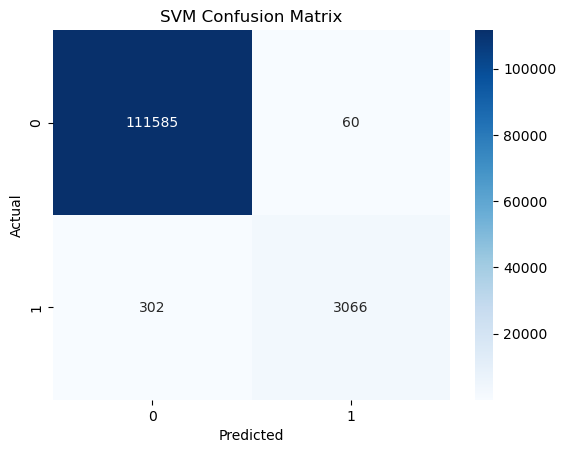

ROC-AUC: 0.9571573478095708


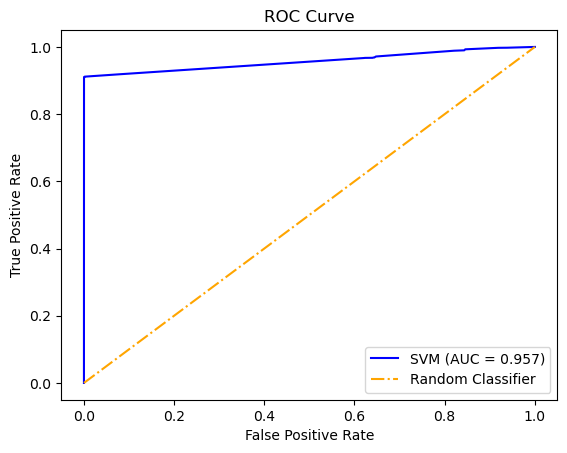

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.svm import SVC
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load preprocessed dataset
df = pd.read_csv("../../Processed_data/processed_hdfs.csv")

print(df.head())
print("Shape:", df.shape)


# Features and labels
x = df.drop(["BlockId", "Label"], axis=1)
y = df["Label"]

print("Normal logs:", sum(y==0))
print("Anomalous logs:", sum(y==1))


# Remove weak features
selector = VarianceThreshold(threshold=0.01)
x = selector.fit_transform(x)


# Log transformation
x = np.log1p(x)


# Train-test split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)


# Feature scaling (important for SVM)
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


# SVM Model
svm = SVC(
    kernel='rbf',
    C=10,
    gamma='auto',
    class_weight='balanced',
    probability=True,
    random_state=42
)


# Train Model
svm.fit(x_train, y_train)


# Predictions
y_pred = svm.predict(x_test)


# Evaluation
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))


# Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()

# ROC AUC Score
y_prob = svm.predict_proba(x_test)[:,1]

auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", auc)


# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, color='blue', label=f'SVM (AUC = {auc:.3f})')
plt.plot([0,1], [0,1], linestyle='dashdot', color='orange', label='Random Classifier')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend(loc="lower right")

plt.show()

                    BlockId  E1  E2   E3  E4  E5  E6  E7  E8  E9  ...  E21  \
0  blk_-1608999687919862906   0   0  203   0  10   7   0   0   3  ...   10   
1   blk_7503483334202473044   0   2    1   0   3   0   0   0   3  ...    3   
2  blk_-3544583377289625738   0   0  203   0   3   0   0   0   3  ...    3   
3  blk_-9073992586687739851   0   3    0   0   3   0   0   0   3  ...    3   
4   blk_7854771516489510256   0   3    1  15   3   0   0   0   3  ...    3   

   E22  E23  E24  E25  E26  E27  E28  E29  Label  
0    1   10    0    4   10    0    0    0      0  
1    1    3    0    0    3    0    0    0      0  
2    1    3    0    0    3    0    0    0      1  
3    1    3    0    0    3    0    0    0      0  
4    1    3    0    0    3    0    0    0      0  

[5 rows x 31 columns]
Shape: (575061, 31)
Normal logs: 558223
Anomalous logs: 16838
Train shape: (460048, 14)
Test shape: (115013, 14)

Confusion Matrix
[[111277    368]
 [   300   3068]]

Classification Report
             

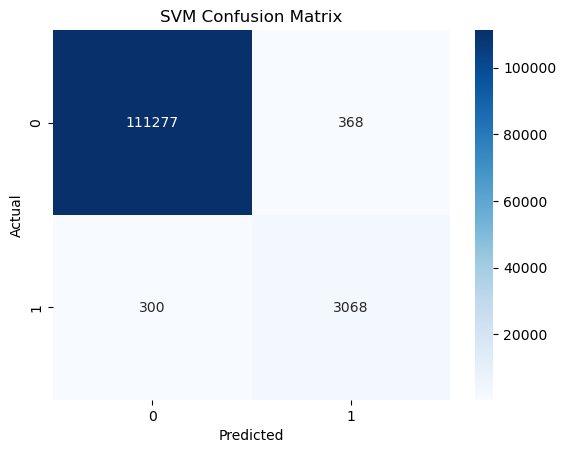

ROC-AUC: 0.9571903566604745


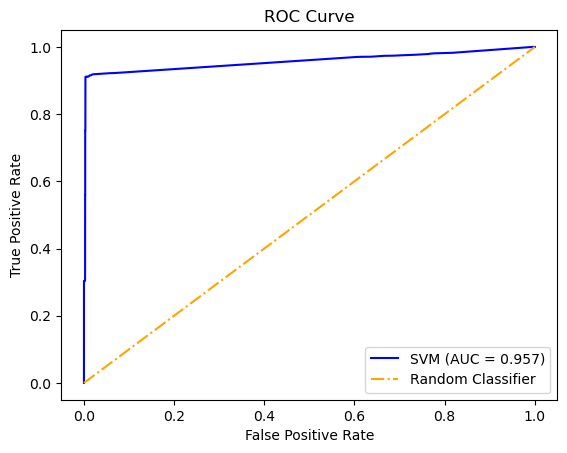

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.svm import SVC, LinearSVC
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# Load preprocessed dataset
df = pd.read_csv("processed_hdfs.csv")

print(df.head())
print("Shape:", df.shape)


# Features and labels
x = df.drop(["BlockId", "Label"], axis=1)
y = df["Label"]

print("Normal logs:", sum(y==0))
print("Anomalous logs:", sum(y==1))


# Remove weak features
selector = VarianceThreshold(threshold=0.01)
x = selector.fit_transform(x)


# Log transformation
x = np.log1p(x)


# Train-test split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)


# Feature scaling (important for SVM)
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


# SVM Model
svm = LinearSVC(
    C=1,
    class_weight='balanced'
)


# Train Model
svm.fit(x_train, y_train)


# Predictions
y_pred = svm.predict(x_test)


# Evaluation
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))



# Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")

plt.show()


# ROC AUC Score
y_prob = svm.decision_function(x_test)

auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", auc)


# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, color='blue', label=f'SVM (AUC = {auc:.3f})')
plt.plot([0,1], [0,1], linestyle='dashdot', color='orange', label='Random Classifier')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend(loc="lower right")

plt.show()